# 01. Trend Analysis: Understanding Patterns Over Time
### Primary Analytical Purpose: *How does the metric change over time?*

Trend analysis investigates how continuous quantitative metrics evolve over an ordered temporal dimension (days, weeks, months, quarters, years). Trend analysis reveals:
- **Direction & Slope:** Is performance increasing, stagnating, or declining? Steeper slope signifies faster rate of change.
- **Seasonality & Cycles:** Are there recurring patterns, such as winter peaks or summer dips?
- **Inflection Points & Turning Points:** When did the growth rate change or shift direction?

---

## 1. Scenario and Dataset Preview
**Scenario:** Qatar Tourism Authority monitors monthly international visitor inflows (in thousands) and hotel occupancy rates across 2025. The objective is to evaluate seasonal fluctuations to plan hotel capacity, public transportation schedules, and national festival programming.

The dataset is loaded from `data/qatar_monthly_visitors.csv`. Let us inspect the data structure and first few records.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

# Set modern Seaborn theme
sns.set_theme(style="whitegrid")

# Load dataset from data folder
df = pd.read_csv("data/qatar_monthly_visitors.csv")

# Display the dataset
print(f"Dataset shape: {df.shape[0]} rows, {df.shape[1]} columns")
df

Dataset shape: 12 rows, 5 columns


,month,month_num,quarter,visitors_thousands,hotel_occupancy_pct
0,Jan,1,Q1,403,76.5
1,Feb,2,Q1,389,74.2
2,Mar,3,Q1,345,68.0
3,Apr,4,Q2,285,59.4
4,May,5,Q2,215,51.2
5,Jun,6,Q2,165,42.8
6,Jul,7,Q3,140,39.5
7,Aug,8,Q3,155,41.0
8,Sep,9,Q3,220,52.3
9,Oct,10,Q4,310,64.7


## 2. Primary Visualization: Line Chart

Demonstrate both **Seaborn** (static, report-ready) and **Plotly Express** (interactive, dashboard-ready). The chart title states the **finding**, not merely the axes.

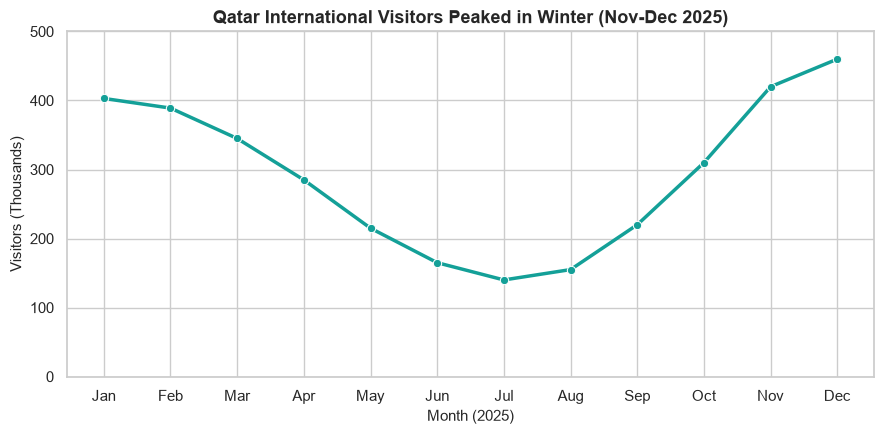

In [2]:
# --- Seaborn Implementation: Static Publication Chart ---
plt.figure(figsize=(9, 4.5))

# Plot monthly visitor line with markers
ax = sns.lineplot(
    data=df, 
    x="month", 
    y="visitors_thousands", 
    marker="o", 
    linewidth=2.5, 
    color="#14A098"
)

# Best practice - Start value axis at zero for measurements
ax.set_ylim(0, 500)

# Best practice - Clear titles stating the finding; clear axis labels
ax.set_title("Qatar International Visitors Peaked in Winter (Nov-Dec 2025)", fontsize=13, weight="bold")
ax.set_xlabel("Month (2025)", fontsize=11)
ax.set_ylabel("Visitors (Thousands)", fontsize=11)

plt.tight_layout()
plt.show()

In [3]:
# --- Plotly Express Implementation: Interactive Dashboard Chart ---
fig = px.line(
    df, 
    x="month", 
    y="visitors_thousands", 
    markers=True,
    title="Qatar International Visitors Peaked in Winter (Nov-Dec 2025)",
    labels={"month": "Month (2025)", "visitors_thousands": "Visitors (Thousands)"}
)

# Set honest axis range starting at zero
fig.update_yaxes(range=[0, 500])
fig.update_traces(line_color="#14A098", line_width=3, marker_size=8)
fig.show()

### Structured Interpretation: The 5-Step Framework

1. **Question:** When does Qatar experience peak international visitor arrivals, and how severe is the summer slowdown?
2. **Visualization:** Monthly line chart with markers, plotted over a continuous zero-based scale.
3. **Observation:** Visitors peaked at 460k in December and 420k in November, while falling to a low of 140k in July.
4. **Insight:** Visitor inflows exhibit pronounced seasonality driven by the winter weather window, with summer arrivals dropping ~70% below December levels.
5. **Implication:** Hospitality and transport operators should schedule heavy maintenance in June–July and scale staff and services for November–February.

## 3. Alternative 1: Area Chart (Cumulative Magnitude)
- **What the chart shows:** The shaded area beneath the line emphasizes the cumulative volume of visitors over the entire period.
- **When to use instead:** Only when the magnitude of a single total matters, or for stacked totals.

In [8]:
# --- Plotly Express: Area Chart ---
fig_area = px.area(
    df, 
    x="month", 
    y="visitors_thousands",
    title="Cumulative Volume: Over 3.2M Visitors Traveled to Qatar in 2025",
    labels={"month": "Month (2025)", "visitors_thousands": "Visitors (Thousands)"}
)

fig_area.update_traces(line_color="#14A098", fillcolor="rgba(20, 160, 152, 0.35)")
fig_area.update_yaxes(range=[0, 500])
fig_area.show()

### Interpretation for Area Chart
- **Observation:** The filled area widens significantly during Q1 (Jan–Mar) and Q4 (Oct–Dec), while dipping into a narrow trough in mid-summer (Jul–Aug).
- **Derived Insight:** Total annual visitor volume reached ~3.27 million, but over 69% of that total arrived during the cooler six months.

## 4. Alternative 2: Column Chart (Few Discrete Periods)
- **What the chart shows:** Total quarterly arrivals displayed as distinct vertical bars.
- **When to use instead:** When time points are few and discrete (e.g., 4 quarters) and each period represents a separate reporting event rather than a continuous daily flow (Slide 9 & 45).

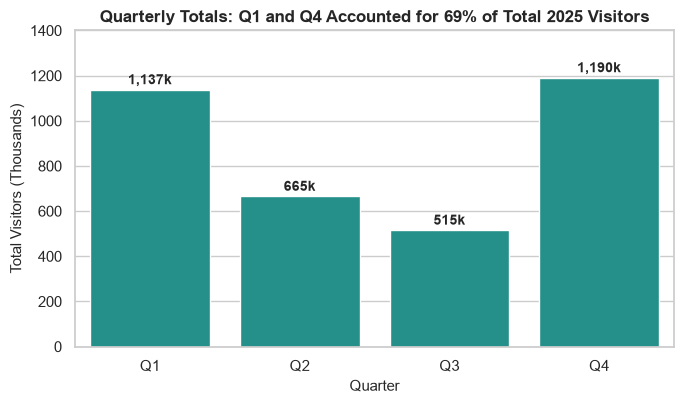

In [5]:
# Aggregate monthly data into quarterly totals
quarterly_df = df.groupby("quarter", as_index=False)["visitors_thousands"].sum()

# --- Seaborn: Quarterly Column Chart ---
plt.figure(figsize=(7, 4.2))
ax_col = sns.barplot(
    data=quarterly_df, 
    x="quarter", 
    y="visitors_thousands", 
    color="#14A098"  # Principle 7: Single intentional colour
)

# Principle 4: Honest zero baseline
ax_col.set_ylim(0, 1400)
ax_col.set_title("Quarterly Totals: Q1 and Q4 Accounted for 69% of Total 2025 Visitors", fontsize=12, weight="bold")
ax_col.set_xlabel("Quarter", fontsize=11)
ax_col.set_ylabel("Total Visitors (Thousands)", fontsize=11)

# Annotate each bar directly with exact values
for p in ax_col.patches:
    height = p.get_height()
    ax_col.annotate(
        f"{int(height):,}k", 
        (p.get_x() + p.get_width() / 2., height + 25), 
        ha='center', 
        fontsize=10, 
        fontweight='bold'
    )

plt.tight_layout()
plt.show()

### Interpretation for Column Chart
- **Observation:** Q4 led with 1,190k visitors, followed closely by Q1 at 1,137k. Q3 had the lowest quarterly volume at 515k.
- **Derived Insight:** Evaluating discrete quarters confirms that the winter half of the year generates more than double the volume of the summer half.

## 5. Key Takeaways
1. **Line charts are the default for trend analysis** because position along continuous time accurately communicates slope and seasonality.
2. **Area charts emphasize cumulative magnitude**, while column charts are best when comparing a few discrete reporting periods.
3. **Always anchor the value axis at zero** for amounts and counts to preserve honest visual proportions.
4. **The title is where the analysis lands:** State the finding in the title, not just the axes.